# 1. Data Collection
## 1.1 What subject is our data about ? 
* **Topic**: The dataset belongs to the Retail and Supply Chain domains. It includes product attributes (weight, visibility, price) and store characteristics (size, location, type).
* **Real-world context**: The retail industry is one of the most data-rich environments. The data scientists at **Big Mart** have collected sales data for 1559 products across 10 stores in different cities. The primary aim is to understand the properties of products and stores which play a crucial role in increasing sales.
## 1.2 What is the source of our data?
* **Platform & URL**: Kaggle - https://www.kaggle.com/datasets/ailearner-researchlab/big-mart-sales-prediction-beginners-choice/data
* **Author**: Curated by AI Learner Research Lab.
* **Date**: The data represents sales records from the year 2013.
## 1.3 Is this data licensed for your use?
* **License**: CC0: Public Domain (Free to use, modify, and distribute for personal or commercial projects).
## 1.4 How was this data collected?
* **Method**: Data was compiled from Point of Sale (POS) transaction systems and internal inventory management databases.
* **Scope**: It covers 1,559 products across 10 different outlets, ranging from small grocery stores to large supermarkets.
## 1.5 Why did we choose this dataset?
* **Interest:** Our group is dedicated to bridging the gap between theory and execution by using a rich, real-world retail dataset to analyze how product and store attributes drive revenue.
* **Potential Insights**: 
    * Identifying whether price, shelf placement, or store type has the most significant impact on sales performance.
    * Building Linear Regression models to forecast **Item_Outlet_Sales** to help businesses optimize inventory and aid in strategic decision-making

# 2. Data Exploration

## 2.1 Dataset Overview

### 2.1.1 Basic Information
This section initializes the dataset and evaluates its fundamental properties:
* **Loading Data:** Reads the `big_mart_sales.csv` file into a Pandas DataFrame.
* **Shape:** Retrieves the total number of rows and columns.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import itertools

In [30]:
# Load the dataset (data/raw/big_mart_sales.csv)
df = pd.read_csv('../data/raw/big_mart_sales.csv')

# Number of rows and columns
rows, cols = df.shape
print(f"Shape: The dataset has {rows} rows and {cols} columns.")

display(df)

df.info()

Shape: The dataset has 8523 rows and 12 columns.


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


### 2.1.2 Data Integrity
This section cleans and verifies the quality of the dataset by:
* **Handling Duplicates:** Identifying and immediately dropping any identical rows to prevent model bias.
* **Missing Values Check:** Verifying the presence of entirely empty rows or missing values (NaNs) to confirm data completeness.

In [31]:
# Duplicates Check
duplicates = df.duplicated().sum()
print(f"Duplicated Rows: {duplicates}")

if duplicates > 0:
    display(df[df.duplicated(keep=False)])
    
# Missing Values Check    
empty_rows = df.isnull().all(axis=1).sum()
total_missing_cells = df.isnull().sum().sum()

print("Row Completeness:")
print(f"- Entirely empty rows: {empty_rows}")
print(f"- Total missing values (NaNs) in the dataset: {total_missing_cells}")

Duplicated Rows: 0
Row Completeness:
- Entirely empty rows: 0
- Total missing values (NaNs) in the dataset: 3873


### 2.1.3 Column Inventory


In [32]:
# Display the column names to verify the inventory
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']


**Meanings & Definitions:**  
* **Product Attributes:**  
    * `Item_Identifier`: Unique product ID.  
    * `Item_Weight`: Weight of the product.  
    * `Item_Fat_Content`: Whether the product is low-fat or regular.  
    * `Item_Visibility`: The percentage of total display area in a store allocated to this specific product.  
    * `Item_Type`: The category to which the product belongs (e.g., Dairy, Soft Drinks, Meat).  
    * `Item_MRP`: Maximum Retail Price (list price) of the product.  

* **Store Attributes:**
    * `Outlet_Identifier`: Unique store ID.
    * `Outlet_Establishment_Year`: The year the store was established.
    * `Outlet_Size`: The size of the store in terms of ground area covered (Small, Medium, High).
    * `Outlet_Location_Type`: The type of city in which the store is located (Tier 1, Tier 2, Tier 3).
    * `Outlet_Type`: The category of the outlet (Grocery Store or Supermarket types).

* **Target Variable:**
    * `Item_Outlet_Sales`: Total sales of the product in the particular store.

### 2.1.4 Data Types

In [33]:
# Display the current data type of each column
print("Current Data Types:")
print(df.dtypes)

Current Data Types:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object


* **Current Data Types:**
    * Numerical (`int64`, `float64`): `Item_Weight`, `Item_Visibility`, `Item_MRP`, `Outlet_Establishment_Year`, and `Item_Outlet_Sales` (Target).
    * Categorical (`object`): `Item_Fat_Content`, `Item_Type`, `Outlet_Size`, `Outlet_Location_Type`, and `Outlet_Type`
* **Inappropriate Data Types:** While `object` (string) types are suitable for initial data exploration and visualization, they are inappropriate for the Linear Regression models, which strictly require numerical inputs for mathematical computation.
* **Type Conversion Needed:** The categorical columns must be converted into numerical formats to be processed by the model.
    * **Label/Ordinal Encoding**: Should be applied to features with an inherent order, such as Outlet_Size (Small, Medium, High) and Outlet_Location_Type.
    * **One-Hot Encoding**: Should be used for non-ordinal categories like `Item_Type` and `Outlet_Type` to prevent the model from assuming a mathematical ranking between them.
    * **Special Handling**: Unique identifiers like `Item_Identifier` and `Outlet_Identifier` may need to be dropped or transformed due to high cardinality.

## 2.2 Numerical Columns Analysis

### 2.2.1 Data Quality
This step evaluates our numerical features to identify missing data, logically impossible values (e.g., negative prices), and hidden placeholders (like `0`).

In [34]:
# Define numerical columns explicitly
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']

print("1. Percentage of Missing Values: ")
missing_percent = (df[num_cols].isnull().sum() / len(df)) * 100
print(missing_percent.round(2).astype(str) + ' %')

print("\n2. Number of Zero Values: ")
zero_counts = (df[num_cols] == 0).sum()
print(zero_counts)

print("\n3. Summary Statistics")
display(df[num_cols].describe())

1. Percentage of Missing Values: 
Item_Weight                  17.17 %
Item_Visibility                0.0 %
Item_MRP                       0.0 %
Outlet_Establishment_Year      0.0 %
Item_Outlet_Sales              0.0 %
dtype: str

2. Number of Zero Values: 
Item_Weight                    0
Item_Visibility              526
Item_MRP                       0
Outlet_Establishment_Year      0
Item_Outlet_Sales              0
dtype: int64

3. Summary Statistics


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


### 2.2.2 Distribution & Central Tendency
In this section, we visualize the numerical variables using **Histograms with Density Plots (KDE)** to understand their distribution shapes (normal, skewed, bimodal) and **Boxplots** to detect potential outliers. Since summary statistics were computed previously, we will focus purely on visual patterns.

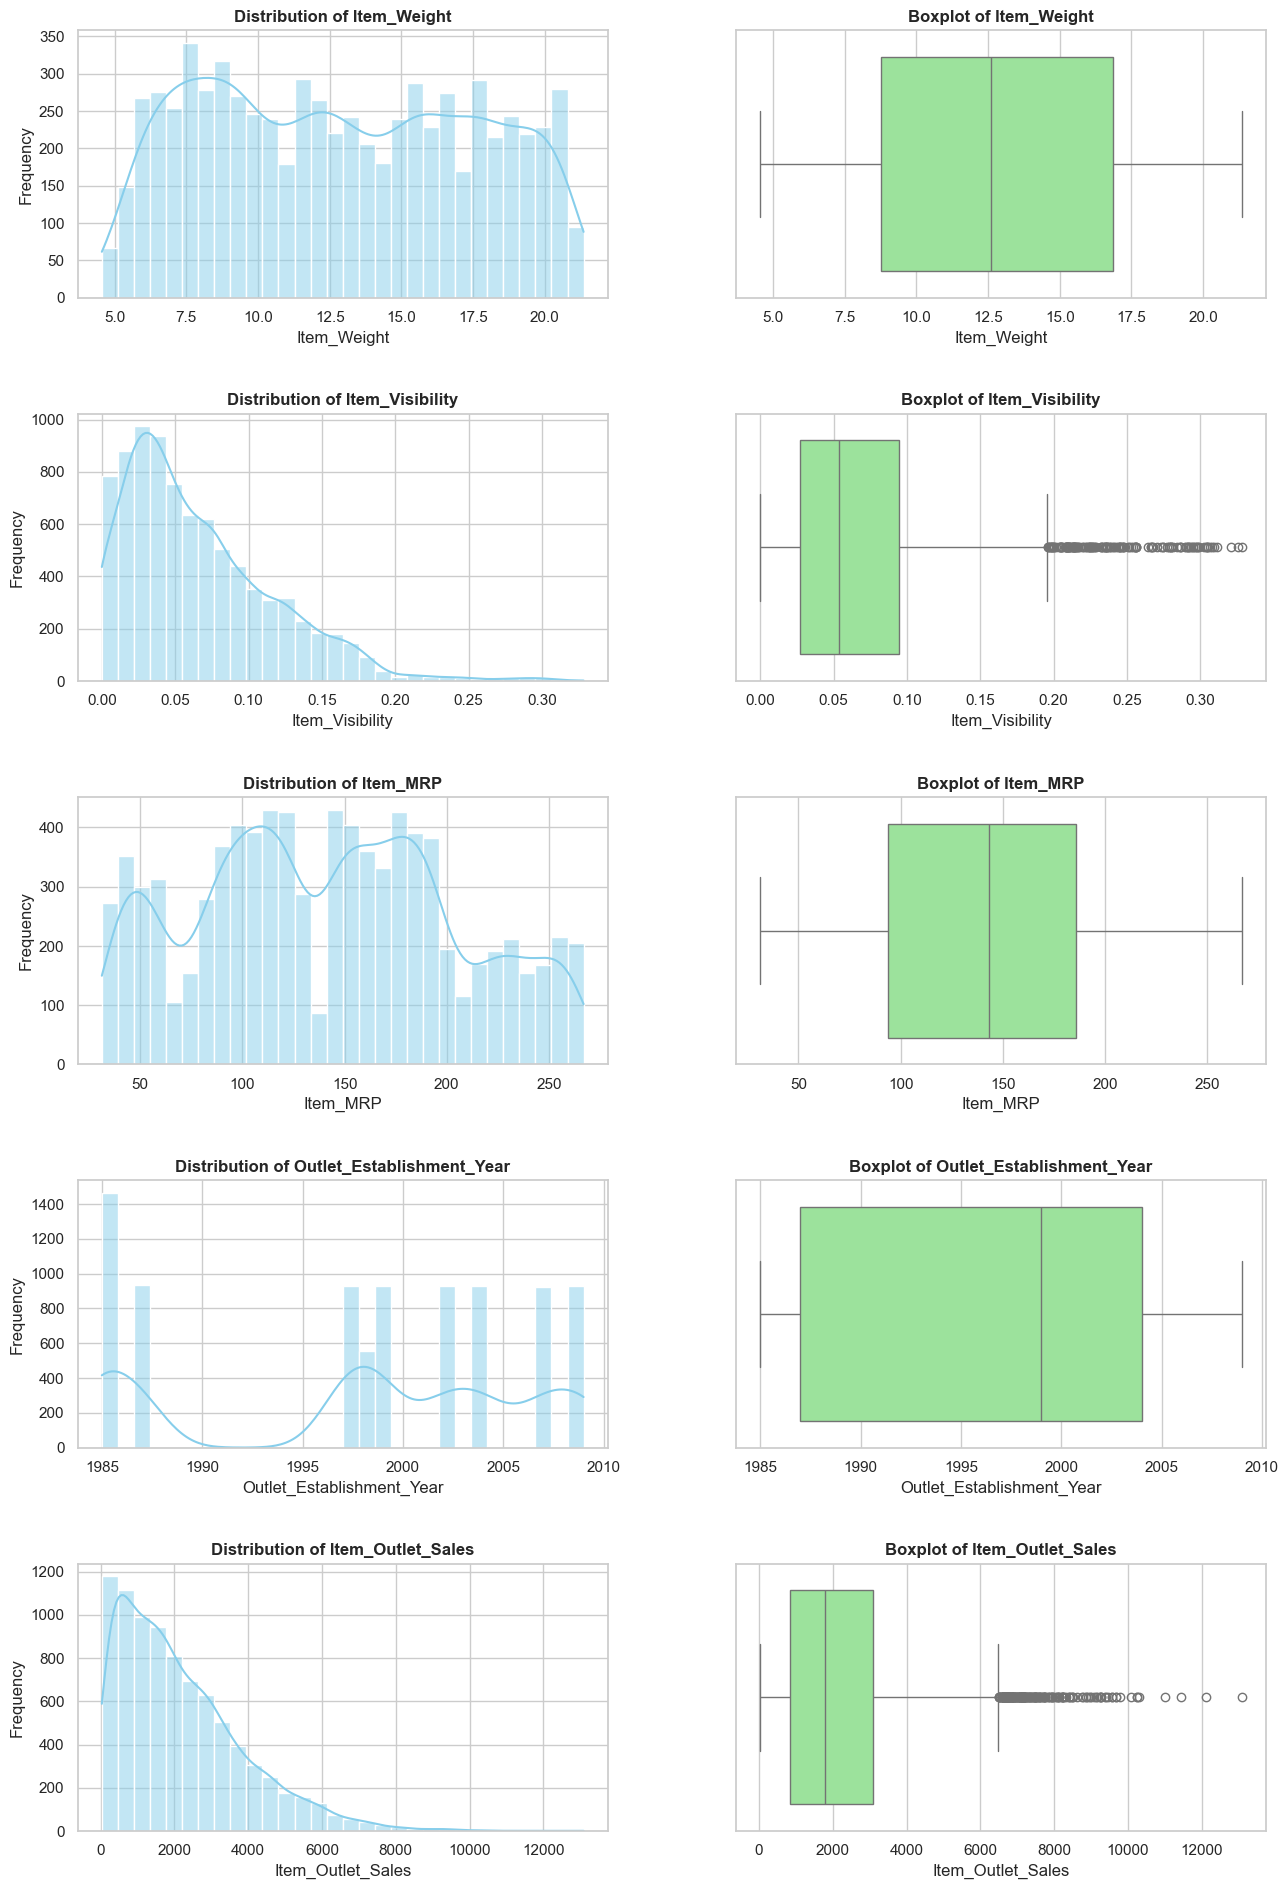

Outliers Count (IQR Method):
- Item_Weight: 0 outliers
- Item_Visibility: 144 outliers
- Item_MRP: 0 outliers
- Outlet_Establishment_Year: 0 outliers
- Item_Outlet_Sales: 186 outliers


In [35]:
# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# The numerical columns defined previously
# Plotting Distributions and Boxplots
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(14, 4 * len(num_cols)))
fig.tight_layout(pad=5.0)

for i, col in enumerate(num_cols):
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue', bins=30)
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')

plt.show()

# Calculating the exact number of outliers using the IQR method
print("Outliers Count (IQR Method):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"- {col}: {outliers_count} outliers")

### 2.2.3 Range & Outliers

All detected outliers are **upper outliers**, appearing only in `Item_Outlet_Sales` and `Item_Visibility`.

* **`Item_Outlet_Sales` (Genuine Extreme Values):** These represent exceptionally popular products or high-performing large stores (e.g., Tier 1 Supermarkets). They are valid business realities, not data entry errors.
* **`Item_Visibility` (Distorted by Placeholders):** While a flagship product might legitimately dominate shelf space, the IQR calculation is currently skewed by the massive number of `0.0` placeholders.
    * **Action:** We must **impute the missing `0.0` values first** before making a final assessment on these upper outliers.

## 2.3 Categorical Columns Analysis

### 2.3.1 Data Quality
This step evaluates our categorical features to identify missing data, spelling inconsistencies, and categories that may need grouping before encoding.

In [36]:
cat_cols = ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

print("1. Percentage of Missing Values\n")
missing_percent_cat = (df[cat_cols].isnull().sum() / len(df)) * 100

# Format and display missing values as a dataframe
missing_df = pd.DataFrame(missing_percent_cat, columns=['Missing (%)']).round(2)
missing_df['Missing (%)'] = missing_df['Missing (%)'].astype(str) + ' %'
display(missing_df)

print("\n2. Unique Count & Values Listing\n")
for col in cat_cols:
    n_unique = df[col].nunique(dropna=False)
    unique_vals = df[col].unique()
    
    # Truncate output for high-cardinality columns
    if n_unique > 20:
        vals_str = ", ".join([f"'{str(val)}'" for val in unique_vals[:5]]) + f" ... (and {n_unique - 5} more)"
    else:
        vals_str = ", ".join([f"'{str(val)}'" for val in unique_vals])
    
    print(f"🔹 {col:<20} | Unique: {n_unique:<4} | Values: {vals_str}")

1. Percentage of Missing Values



,Missing (%)
Item_Identifier,0.0 %
Item_Fat_Content,0.0 %
Item_Type,0.0 %
Outlet_Identifier,0.0 %
Outlet_Size,28.28 %
Outlet_Location_Type,0.0 %
Outlet_Type,0.0 %



2. Unique Count & Values Listing

🔹 Item_Identifier      | Unique: 1559 | Values: 'FDA15', 'DRC01', 'FDN15', 'FDX07', 'NCD19' ... (and 1554 more)
🔹 Item_Fat_Content     | Unique: 5    | Values: 'Low Fat', 'Regular', 'low fat', 'LF', 'reg'
🔹 Item_Type            | Unique: 16   | Values: 'Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables', 'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods', 'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned', 'Breads', 'Starchy Foods', 'Others', 'Seafood'
🔹 Outlet_Identifier    | Unique: 10   | Values: 'OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045', 'OUT017', 'OUT046', 'OUT035', 'OUT019'
🔹 Outlet_Size          | Unique: 4    | Values: 'Medium', 'nan', 'High', 'Small'
🔹 Outlet_Location_Type | Unique: 3    | Values: 'Tier 1', 'Tier 3', 'Tier 2'
🔹 Outlet_Type          | Unique: 4    | Values: 'Supermarket Type1', 'Supermarket Type2', 'Grocery Store', 'Supermarket Type3'


**Categorical Data Quality Observations:**

* **Missing Values:** `Outlet_Size` is missing approximately **28.28%** of its data (labeled as `NaN`). All other categorical columns are 100% complete.
* **Inconsistencies & Typos:** The `Item_Fat_Content` column has inconsistent data entry. It contains *Low Fat*, *LF*, and *low fat* (which all mean the same thing), as well as *Regular* and *reg* (which also mean the same). 
    * **Action:** We must standardize these into just two categories: 'Low Fat' and 'Regular'.

### 2.3.2 Value Distribution

1. Value Counts

--- Item_Fat_Content ---
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


--- Item_Type ---
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


--- Outlet_Size ---
Outlet_Size
Medium     2793
Missing    2410
Small      2388
High        932
Name: count, dtype: int64


--- Outlet_Location_Type ---
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64


--- Outlet_Type ---
Outlet_Type
Supermarket Type1 

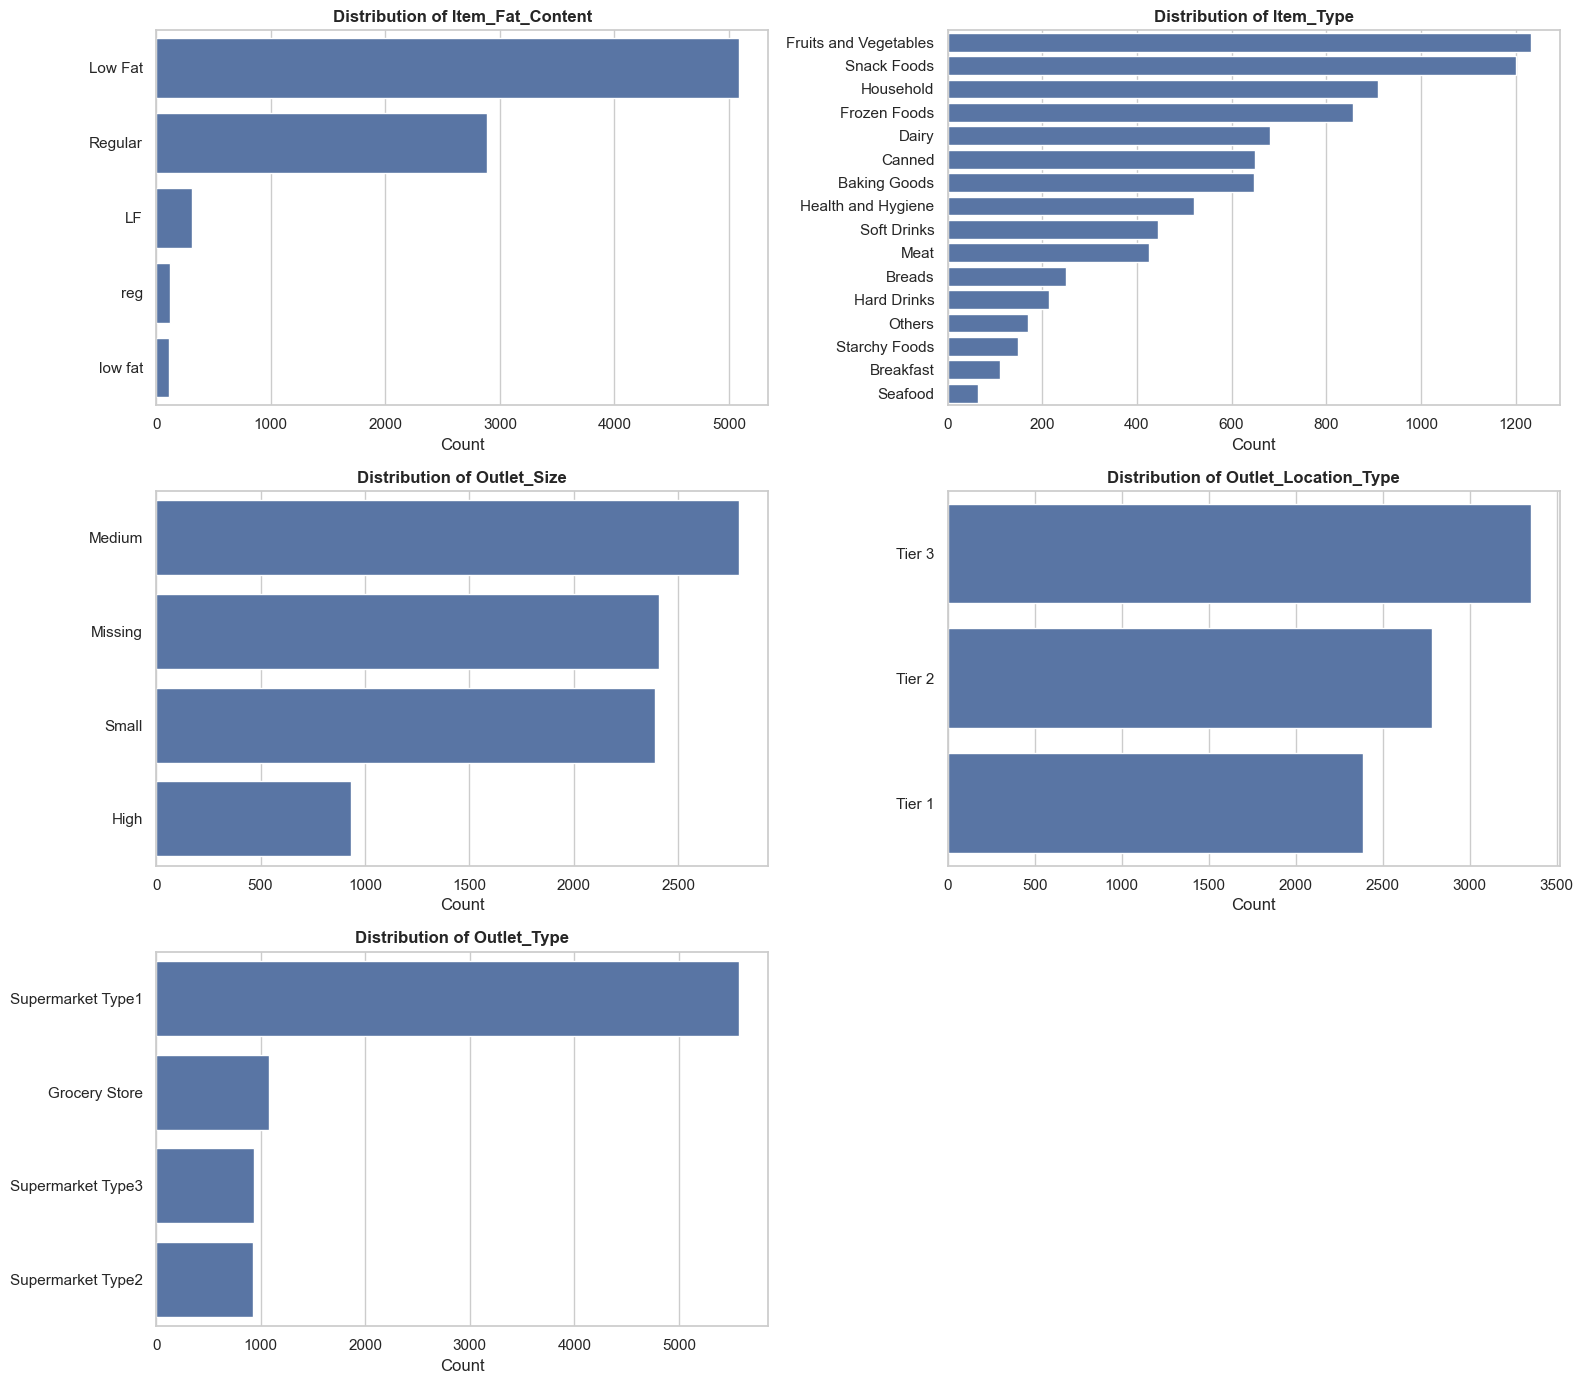

In [37]:
# Define columns to visualize (excluding IDs)
cols_to_plot = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

print("1. Value Counts\n")
for col in cols_to_plot:
    print(f"--- {col} ---")
    print(df[col].fillna('Missing').value_counts())
    print("\n")

print("2. Visualizing Value Distributions\n")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    # Cast to string to prevent float errors in Matplotlib
    plot_data = df[col].fillna('Missing').astype(str)
    
    # Get the order of categories from highest to lowest count
    order = plot_data.value_counts().index 
    
    # Create the countplot
    sns.countplot(y=plot_data, ax=axes[i], order=order)
    
    # Formatting
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

# Hide the last empty subplot (6th plot is not needed)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 2.4 Missing Data Analysis: Overall Assessment

Before handling missing values, we need to understand their scale and patterns. 
* **Quantitative Summary:** We calculate the exact count and percentage for every column.
* **Pattern Visualization:** We use a heatmap to see if missing values occur in specific clusters or across certain rows, helping us determine if the data is Missing Completely at Random (MCAR) or follows a specific pattern.

Data Quality Issues (NaNs + Zero Placeholders)
Item_Weight        17.17 %
Item_Visibility     6.17 %
Outlet_Size        28.28 %
dtype: str


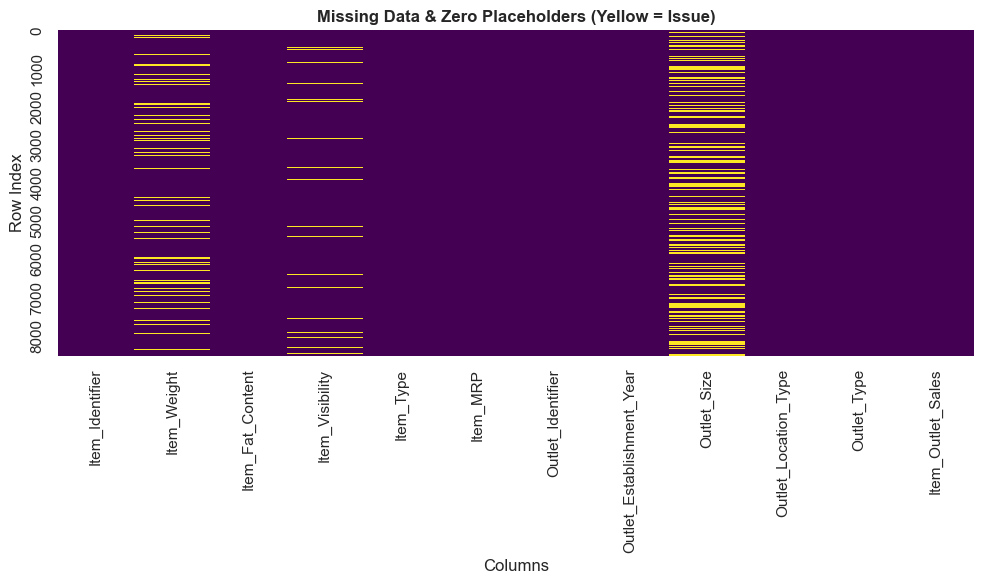

In [38]:
# True if value is NaN OR if Item_Visibility is 0
analysis_mask = df.isnull().copy()
analysis_mask['Item_Visibility'] = analysis_mask['Item_Visibility'] | (df['Item_Visibility'] == 0)

print("Data Quality Issues (NaNs + Zero Placeholders)")
# Calculate combined issues percentage
total_issues = analysis_mask.sum() / len(df) * 100
print(total_issues[total_issues > 0].round(2).astype(str) + ' %')

# Visualize all issues in one heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(analysis_mask, cbar=False, cmap='viridis', yticklabels=1000)

plt.title('Missing Data & Zero Placeholders (Yellow = Issue)', fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Row Index')
plt.tight_layout()
plt.show()

**Final Data Quality Observations:**

* **Spread of Issues:** The heatmap confirms that missing values (`NaN`) and zero placeholders are **uniformly spread** across the entire dataset (8,523 rows).
* **Quantifying the Gaps:**
    * **`Item_Weight`:** Missing **17.17%** (NaN).
    * **`Outlet_Size`:** Missing **28.28%** (NaN).
    * **`Item_Visibility`:** Contains **6.17%** zero placeholders (`0.0`). Logically, a product on a shelf cannot have zero visibility; therefore, these are treated as missing data.
* **Implication:** Because these issues are spread evenly rather than clustered in a few rows, dropping the affected data would delete over 30% of the dataset. **Grouped Imputation** is required to preserve data integrity.

## 2.5 Relationships & Correlation

### 2.5.1 Preliminary Patterns

In this section, we explore the linear relationships between the numerical variables in our dataset.

To emphasize the **strength** (magnitude) of these relationships rather than their direction (positive/negative), we will compute the **Absolute Correlation Matrix**. 

* **Methodology:** We calculate the Pearson correlation coefficients for all numerical columns and convert them to absolute values (ranging from 0 to 1).
* **Visualization:** We use a heatmap with the `viridis` color palette. Darker/brighter colors will immediately highlight the pairs of variables that have the strongest predictive relationship with each other.

=== Absolute Correlation Matrix ===


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000,0.014,0.027,0.012,0.014
Item_Visibility,0.014,1.000,0.001,0.075,0.129
Item_MRP,0.027,0.001,1.000,0.005,0.568
Outlet_Establishment_Year,0.012,0.075,0.005,1.000,0.049
Item_Outlet_Sales,0.014,0.129,0.568,0.049,1.000


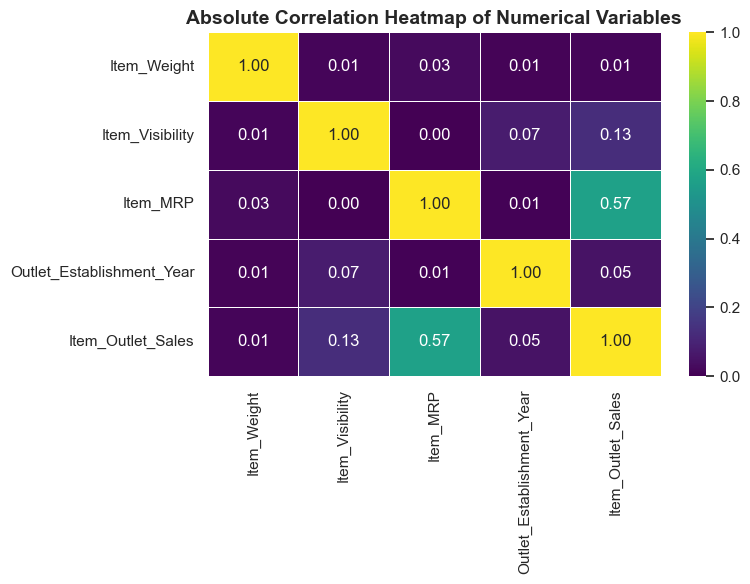

In [39]:
num_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']

# Calculate the correlation matrix and get absolute values
corr_matrix = df[num_cols].corr()
corr_matrix_abs = corr_matrix.abs()

print("=== Absolute Correlation Matrix ===")
display(corr_matrix_abs.round(3))

# Create a heatmap using the viridis palette
plt.figure(figsize=(8, 6))
# Set vmin=0 since absolute correlation values range from 0 to 1
sns.heatmap(corr_matrix_abs, annot=True, cmap='viridis', fmt=".2f", vmin=0, vmax=1, linewidths=0.5)
plt.title('Absolute Correlation Heatmap of Numerical Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

* **Strongest Predictor:** `Item_MRP` (0.568) has the strongest positive correlation with `Item_Outlet_Sales`. As expected, higher-priced items generate more revenue per transaction.
* **Insignificant Features:** `Item_Weight` (0.014) and `Outlet_Establishment_Year` (0.049) show almost zero linear relationship with sales.
* **Surprising Finding:** `Item_Visibility` (0.129) has a surprisingly weak correlation with sales. Counter-intuitively, products taking up more display space do not linearly guarantee higher sales (this may be skewed by the `0.0` missing values).

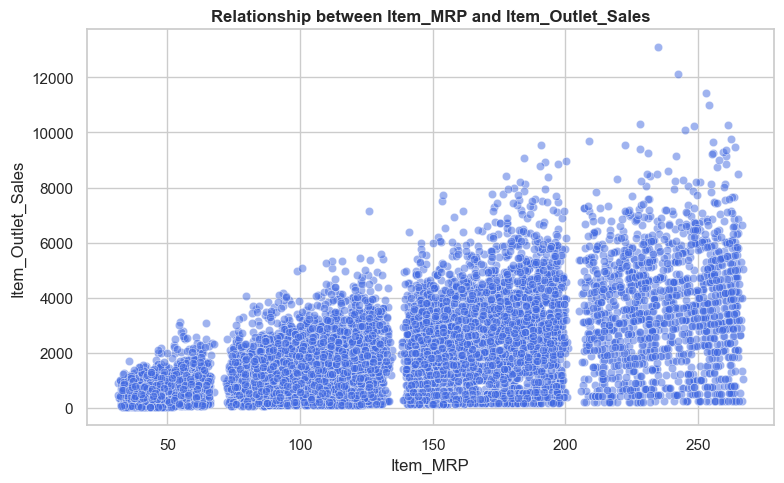

In [40]:
# Plotting the relationship between Item_MRP and Item_Outlet_Sales
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, alpha=0.5, color='royalblue')
plt.title('Relationship between Item_MRP and Item_Outlet_Sales', fontweight='bold')
plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')
plt.tight_layout()
plt.show()

### 2.5.1 Frequency Heatmaps

#### Categorical x Categorical

1. Categorical x Categorical: ALL Frequency Plots (with counts):



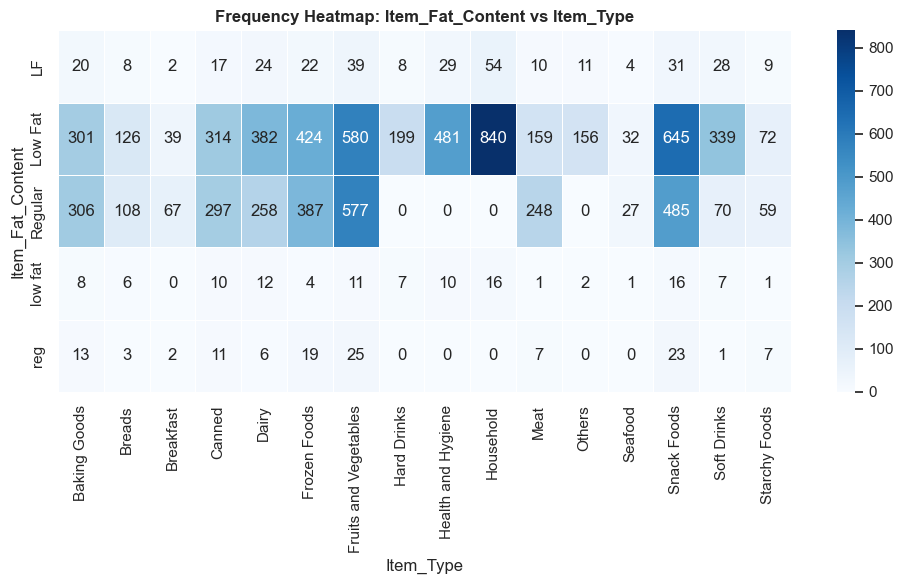

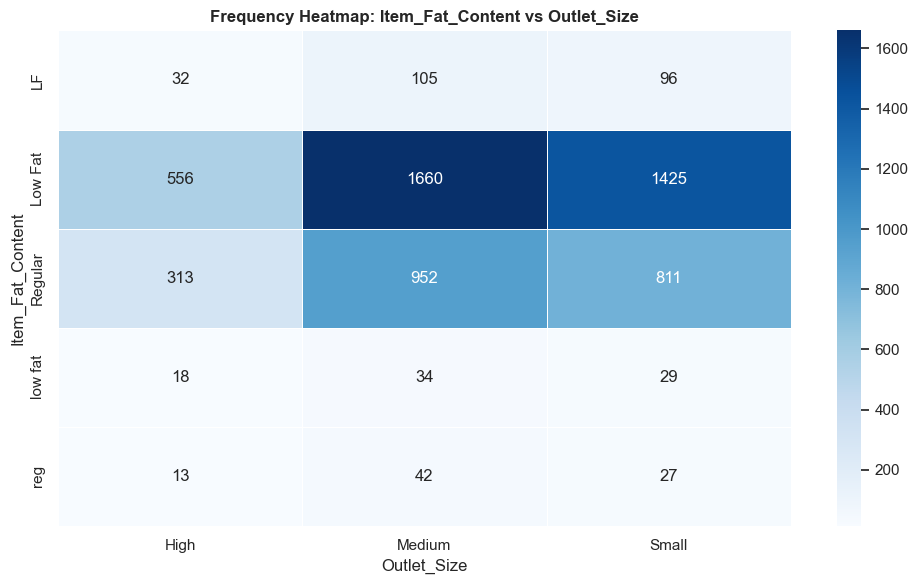

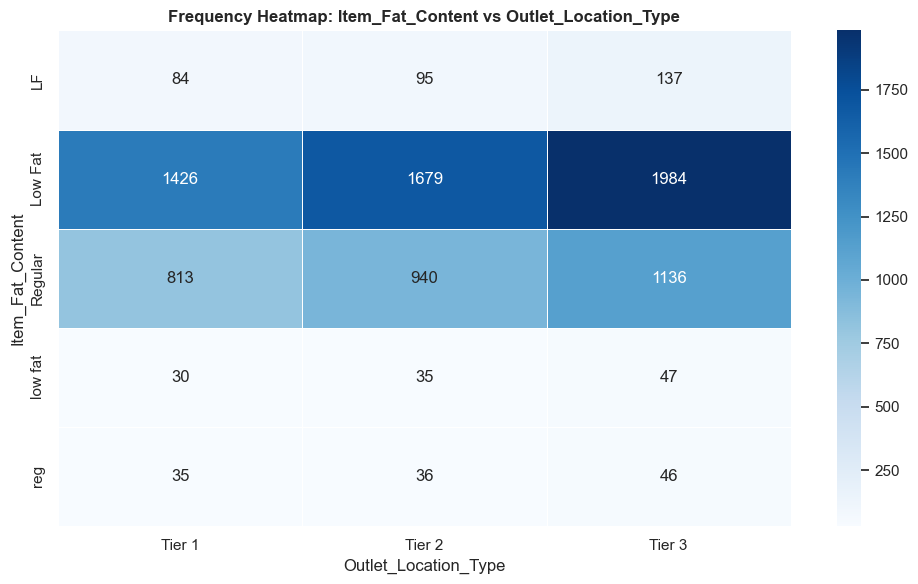

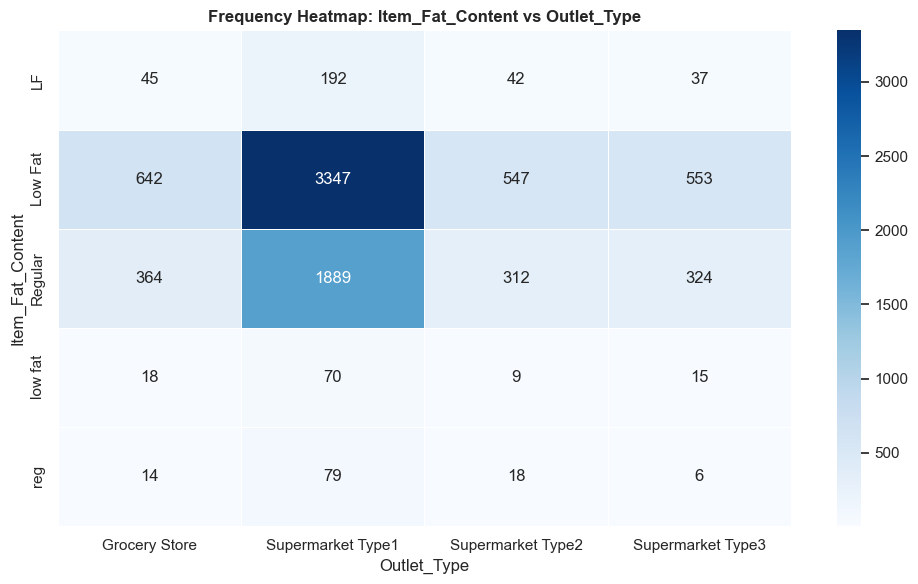

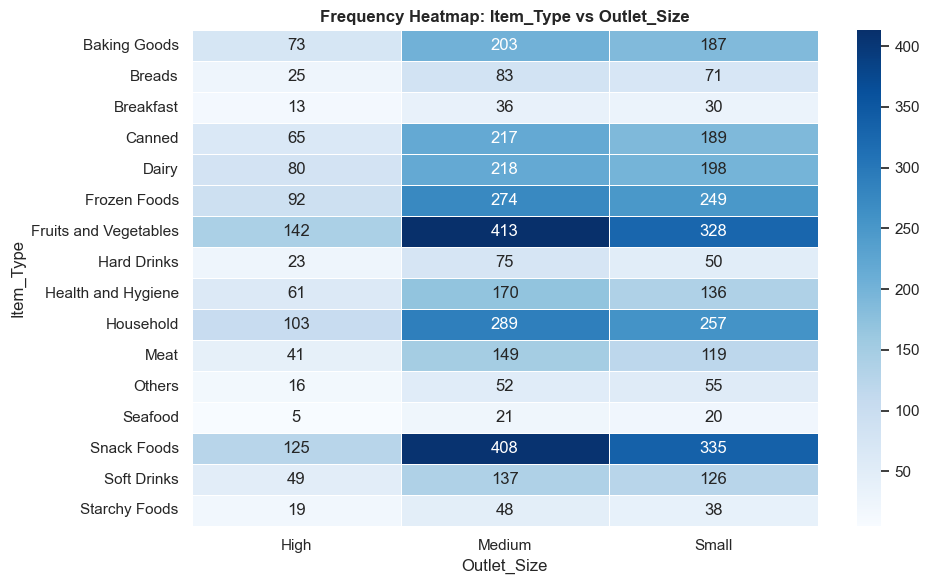

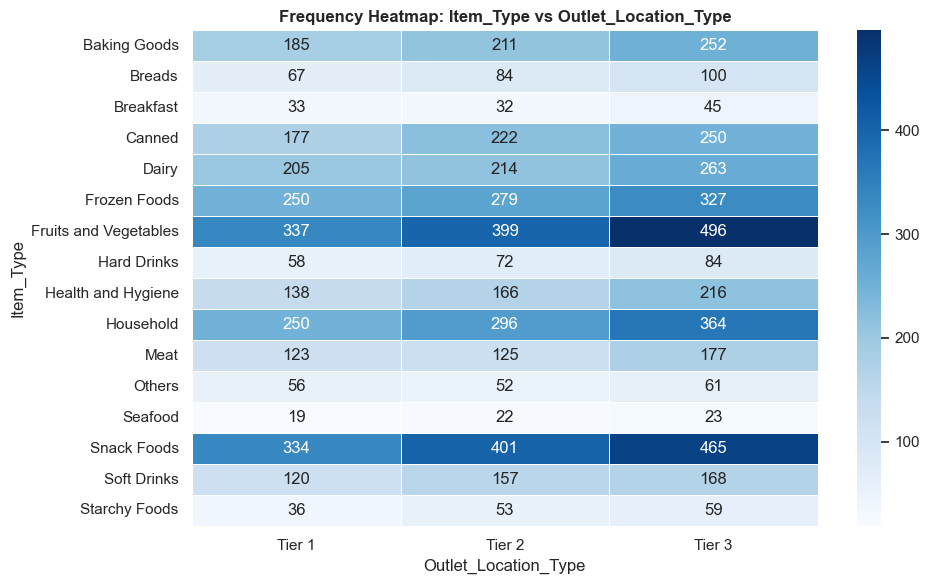

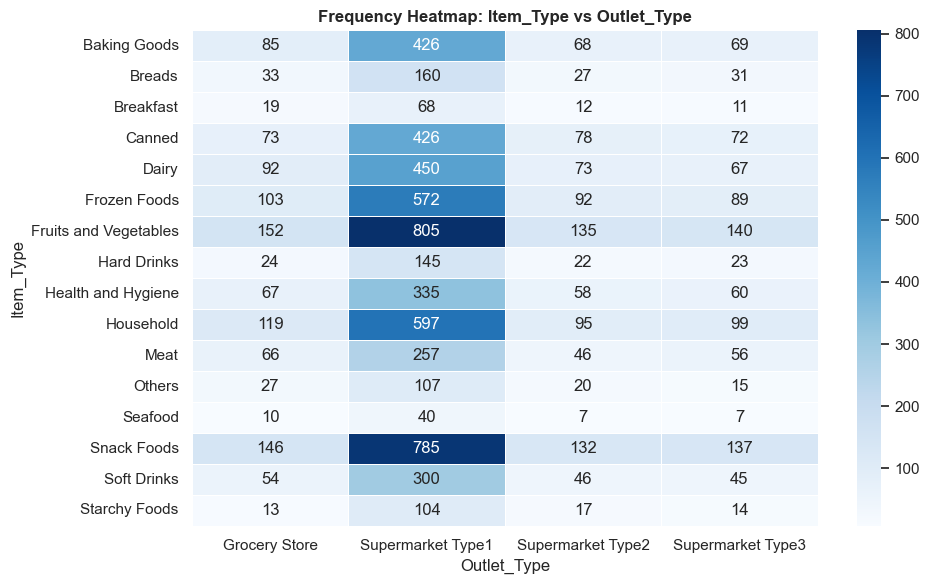

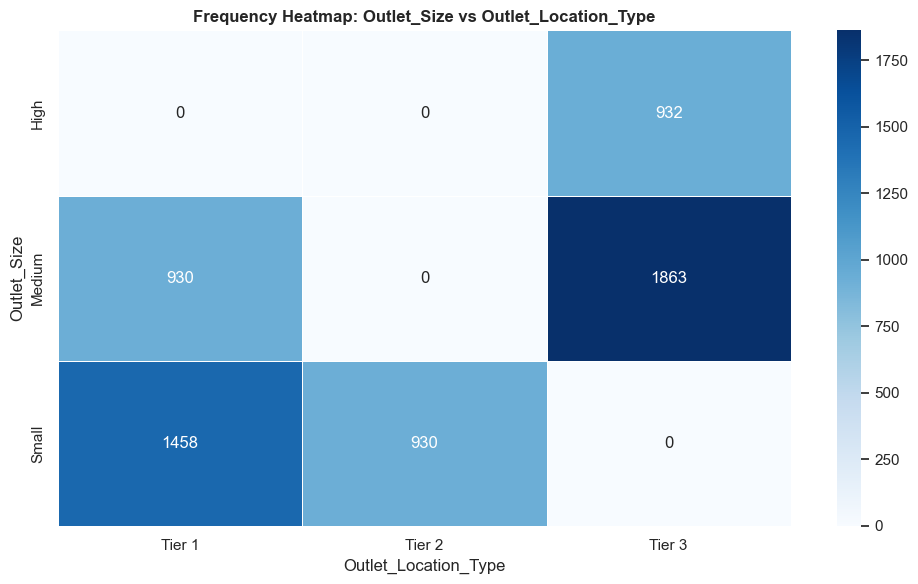

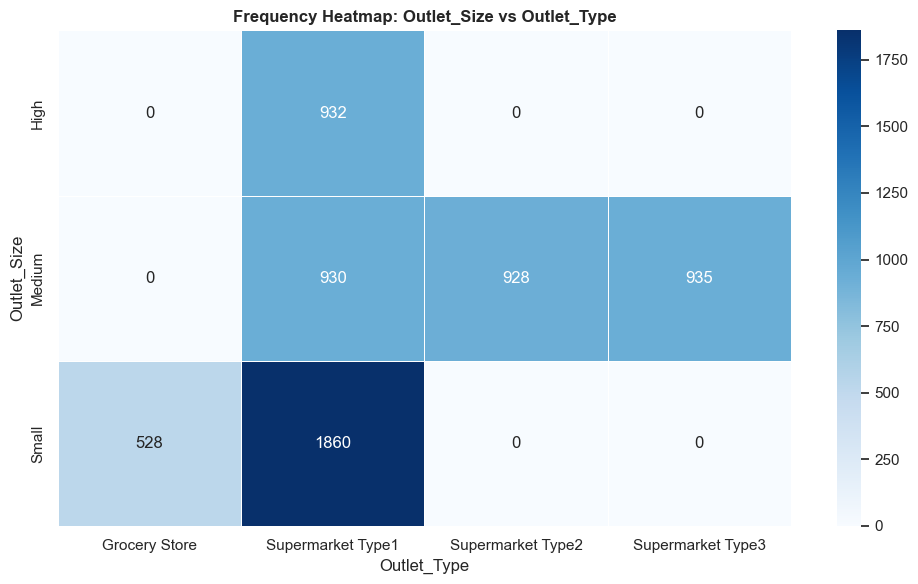

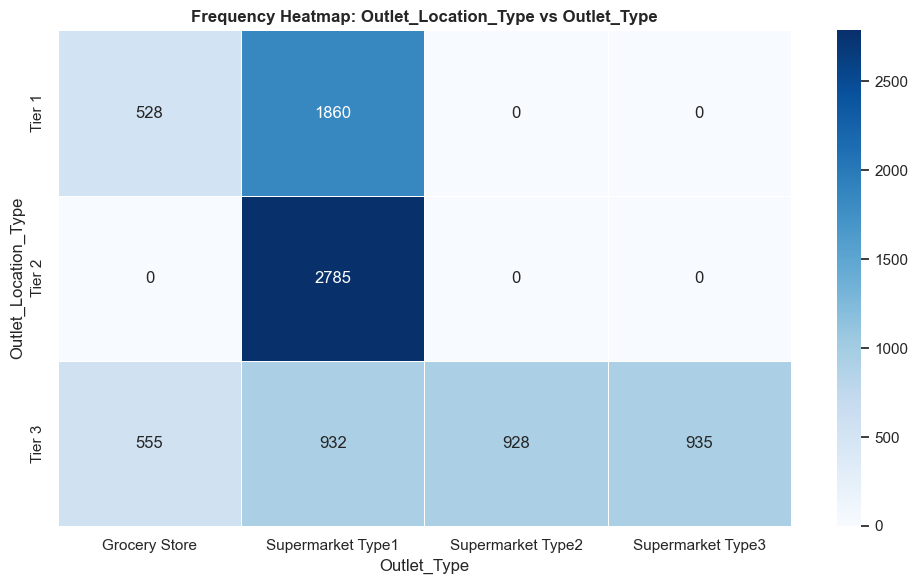

In [41]:
# List of important categorical variables (Excluding Item_Identifier as it has 1559 unique values)
cat_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

print("1. Categorical x Categorical: ALL Frequency Plots (with counts):\n")
# Create all possible combinations of 2 columns from the cat_cols list
all_cat_pairs = list(itertools.combinations(cat_cols, 2))

for col1, col2 in all_cat_pairs:
    plt.figure(figsize=(10, 6))
    cross_tab = pd.crosstab(df[col1], df[col2])
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', cbar=True, linewidths=0.5)
    plt.title(f'Frequency Heatmap: {col1} vs {col2}', fontweight='bold')
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.tight_layout()
    plt.show()

#### Investigating Item_Identifier naming conventions

2. Investigating Item_Identifier naming conventions:


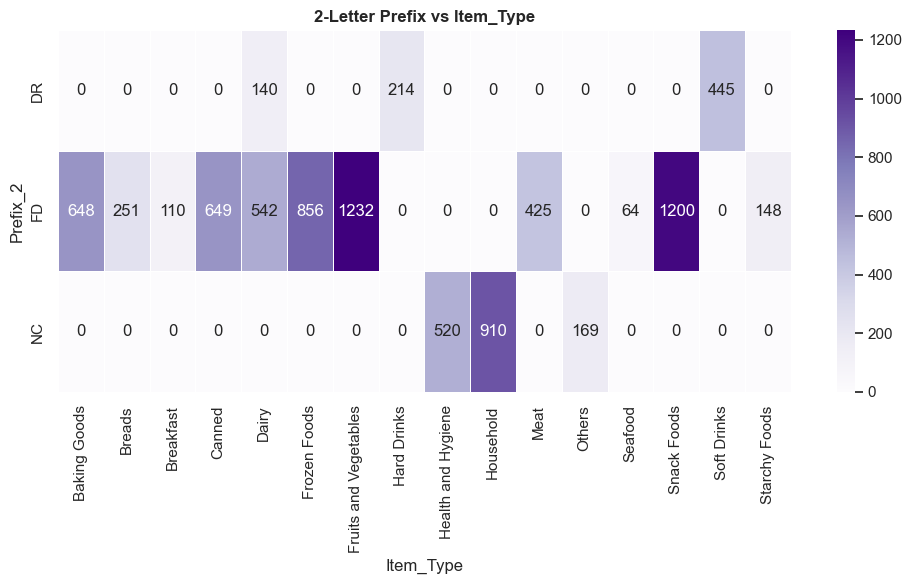

In [42]:
# PROVING THE ID-TYPE RELATIONSHIP
print("2. Investigating Item_Identifier naming conventions:")

# Testing different prefix lengths to find the category mapping
df['Prefix_2'] = df['Item_Identifier'].str[:2]
df['Prefix_3'] = df['Item_Identifier'].str[:3]

plt.figure(figsize=(10, 6))
prefix_type_tab = pd.crosstab(df['Prefix_2'], df['Item_Type'])
sns.heatmap(prefix_type_tab, annot=True, fmt='d', cmap='Purples', cbar=True, linewidths=0.5)
plt.title('2-Letter Prefix vs Item_Type', fontweight='bold')
plt.xlabel('Item_Type')
plt.ylabel('Prefix_2')
plt.tight_layout()
plt.show()

#### Numerical x Categorical


3. Numerical x Categorical: Sales Summary by ALL Categories (using boxplots):



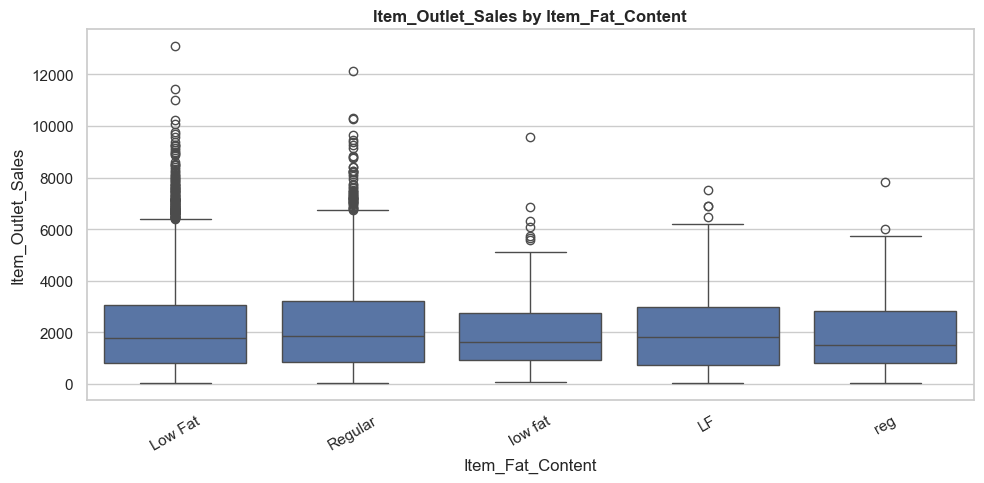

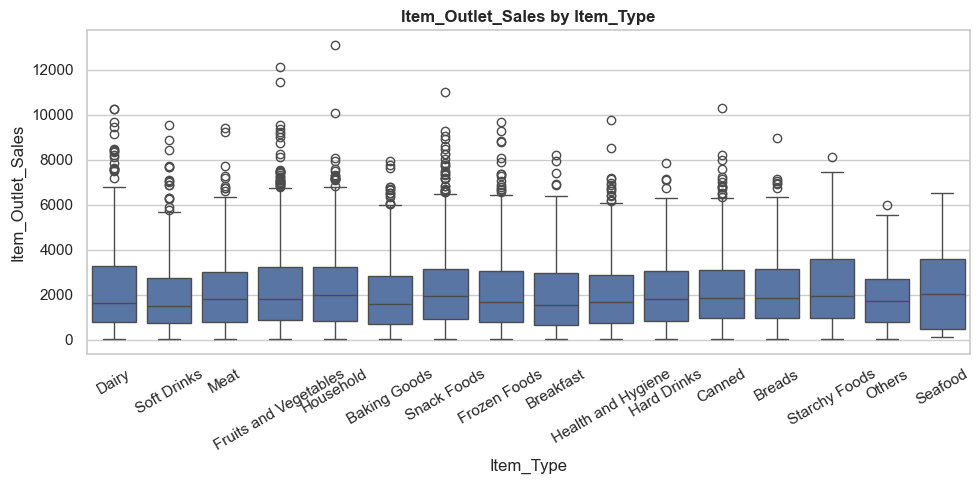

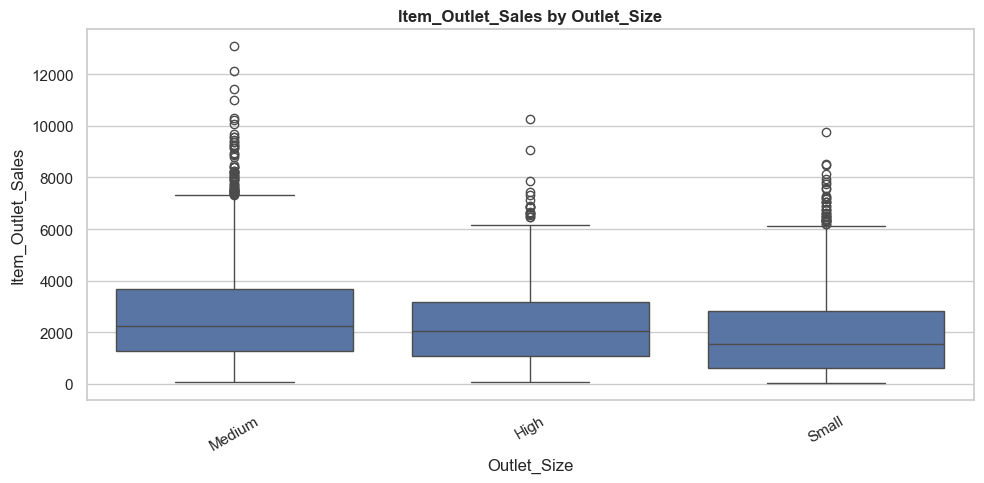

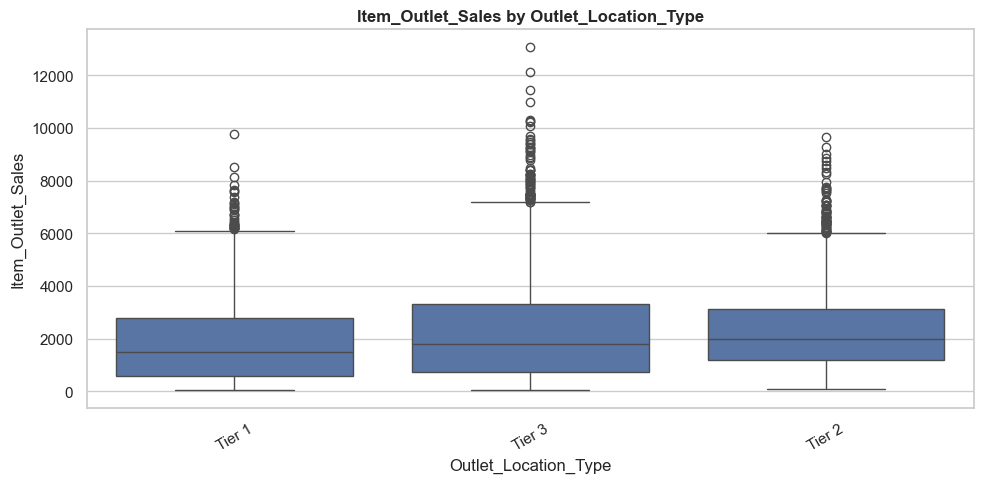

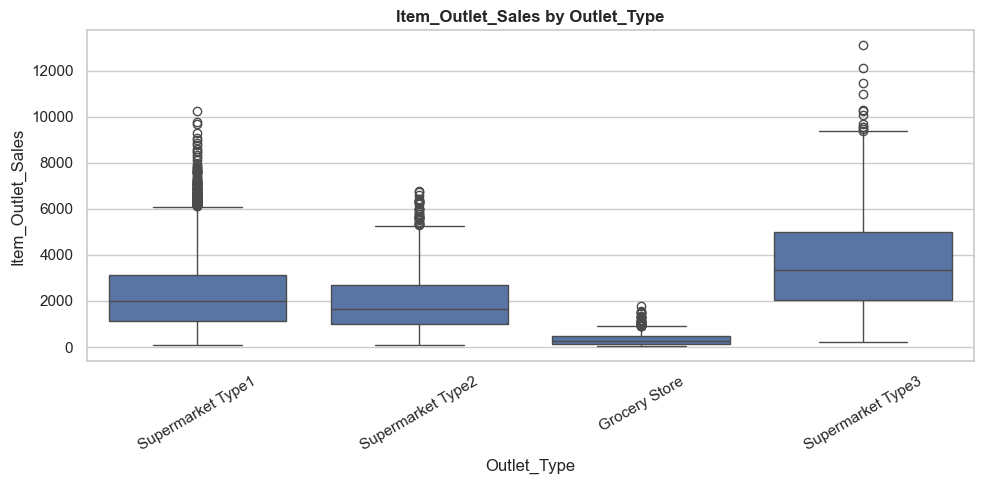

In [43]:
print("\n3. Numerical x Categorical: Sales Summary by ALL Categories (using boxplots):\n")

# Boxplots for Item_Outlet_Sales by each categorical variable
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='Item_Outlet_Sales', data=df)
    plt.title(f'Item_Outlet_Sales by {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Item_Outlet_Sales')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# 3. Initial Observations & Insights

## 3.1 Summary

**1. 3-5 Key Observations:**
* **Price Drives Revenue:** `Item_MRP` (Maximum Retail Price) is the single strongest numerical predictor of `Item_Outlet_Sales` (correlation ~ 0.57). 
* **Store Type is Crucial:** `Outlet_Type` heavily dictates performance. `Supermarket Type 3` generates the highest average sales, while `Grocery Stores` generate the lowest.
* **Visibility Paradox:** Counter-intuitively, `Item_Visibility` has a weak correlation with sales. Items taking up more display space do not necessarily generate more revenue.
* **Location Strategy:** The business has a specific deployment strategy (e.g., `Supermarket Type 3` is exclusively in `Tier 3` locations, and `Tier 2` only hosts `Supermarket Type 1`).

**2. Data Quality Issues Identified:**
* **Missing Values:** `Item_Weight` is missing 17.17% of its data, and `Outlet_Size` is missing 28.28%.
* **Placeholder Values:** `Item_Visibility` has a minimum value of `0.0` (affecting 6.17% of rows), which is physically impossible for items displayed in a store.
* **Inconsistent Categorical Labels:** `Item_Fat_Content` contains inconsistencies ('LF', 'low fat', 'reg' instead of standard 'Low Fat' and 'Regular').
* **Logical Flaws:** Non-consumable item types (like 'Household' and 'Health and Hygiene') are assigned a fat content ('Low Fat'), which makes no sense.

**3. Necessary Preprocessing Steps (Next Phase):**
* **Handle Missing Data:** Develop a strategy to impute or handle the significant gaps in `Item_Weight` and `Outlet_Size` without losing valuable rows.
* **Address Placeholders:** Treat the `0.0` values in `Item_Visibility` as missing data and resolve them appropriately.
* **Standardize Text:** Clean and unify the inconsistent text labels in the `Item_Fat_Content` column.
* **Fix Logical Inconsistencies:** Restructure categories to properly separate consumable food items from non-edible products.

## 3.2 Limitations Affecting Analysis
* **Lack of Time-Series Data:** We only have aggregated total sales (`Item_Outlet_Sales`). We lack transactional data (e.g., daily/monthly sales, seasonality, or customer demographics), which limits our ability to forecast trends over time.
* **Relative Age:** We have `Outlet_Establishment_Year`, but we don't know the exact year this dataset was compiled. We will need to convert this into a relative feature (e.g., `Outlet_Age` = Data_Collection_Year - Establishment_Year) to make it useful for the model.